In [42]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel("data\Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx", sheet_name = 16,header=None)


df.head(10)


<>:8: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:8: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_14328\1709598715.py:8: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_excel("data\Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx", sheet_name = 16,header=None)


,0,1,2,3,4,5,6,7,8,9
0,NaN,Table 15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Exports of Major Commodities to India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,(Rs. in million),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,S.N.,Heading,2023/24R,NaN,2024/25R,NaN,2025/26P,Percent Change,NaN
5,NaN,NaN,NaN,Annual,Six Months,Annual,Six Months,Six Months,2024/25,2025/26
6,NaN,NaN,A. Major Commodities,82060.897913,40715.122573,187247.527279,58736.949914,97533.378993,44.263228,66.051147
7,NaN,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
8,NaN,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
9,NaN,3,Cattlefeed,0.061,0.061,0,0,0,-,-


In [43]:
df = df.drop(columns =[0])

df = df.iloc[7:].reset_index(drop=True) #removing 1 to 6 th rows
df = df.iloc[:-4].reset_index(drop=True)

# replacing - with 0
df = df.replace('-', 0)
df.head()

,1,2,3,4,5,6,7,8,9
0,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
2,3,Cattlefeed,0.061,0.061,0,0,0,0,0
3,4,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.69342,-25.879216,-22.109289
4,5,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


In [44]:
df.columns = [
    'S.N.',
    'Commodities',
    '2023/24 Annual',
    '2023/24 Six Months',
    '2024/25 Annual',
    '2024/25 Six Months',
    '2025/26 Six Months',
    '2024/25 Growth %',
    '2025/26 Growth %'
]
df.head()

,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
2,3,Cattlefeed,0.061,0.061,0,0,0,0,0
3,4,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.69342,-25.879216,-22.109289
4,5,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


In [45]:
# # checking empty data or data handling
# print(df.isnull().sum())

# # checking du-plicates data
# print(df.duplicated().sum())



In [46]:
#shows the total number of row and columns
df.shape

(38, 9)

In [47]:

print(df.columns)

Index(['S.N.', 'Commodities', '2023/24 Annual', '2023/24 Six Months',
       '2024/25 Annual', '2024/25 Six Months', '2025/26 Six Months',
       '2024/25 Growth %', '2025/26 Growth %'],
      dtype='str')


In [48]:
print(len(df))

38


In [49]:
total_202324_annual = df["2023/24 Annual"].sum()
total_202425_annual = df["2024/25 Annual"].sum()
total_202324_sixmnth = df["2023/24 Six Months"].sum()
total_202425_sixmnth = df["2024/25 Six Months"].sum()
total_202526_sixmnth = df["2025/26 Six Months"].sum()

print(f"2023/24 Annual Sum: {total_202324_annual}")
print(f"2024/25 Annual Sum: {total_202425_annual}")
print(f"2023/24 Six Months Sum: {total_202324_sixmnth}")
print(f"2024/25 Six Months Sum: {total_202425_sixmnth}")
print(f"2025/26 Six Months Sum: {total_202526_sixmnth}")

2023/24 Annual Sum: 88816.67426880001
2024/25 Annual Sum: 195470.4693294
2023/24 Six Months Sum: 44340.72146009999
2024/25 Six Months Sum: 62079.23856560002
2025/26 Six Months Sum: 102653.413809


In [50]:
df.head()

,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
2,3,Cattlefeed,0.061,0.061,0,0,0,0,0
3,4,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.69342,-25.879216,-22.109289
4,5,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


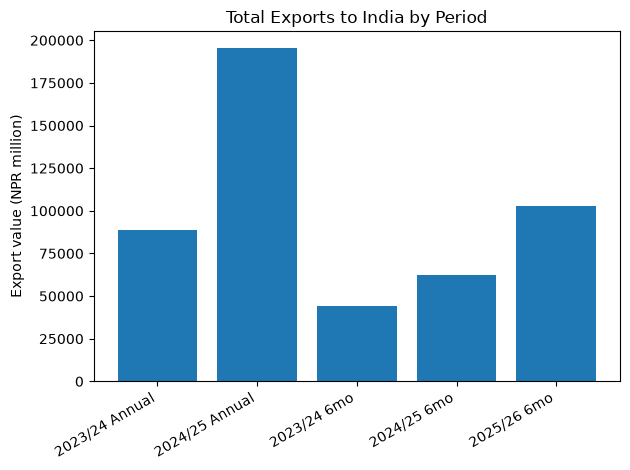

In [51]:

labels = ['2023/24 Annual', '2024/25 Annual', '2023/24 6mo', '2024/25 6mo', '2025/26 6mo']
totals = [total_202324_annual, total_202425_annual, total_202324_sixmnth, total_202425_sixmnth, total_202526_sixmnth]

fig, ax = plt.subplots()

x_pos = np.arange(len(labels))
ax.bar(x_pos, totals, align='center')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=30, ha='right')  # rotate so labels don't overlap
ax.set_ylabel('Export value (NPR million)')
ax.set_title('Total Exports to India by Period')

plt.tight_layout()
plt.show()

In [52]:
print(df.dtypes)

S.N.                  object
Commodities              str
2023/24 Annual        object
2023/24 Six Months    object
2024/25 Annual        object
2024/25 Six Months    object
2025/26 Six Months    object
2024/25 Growth %      object
2025/26 Growth %      object
dtype: object


In [53]:
df['2025/26 Growth %'] = pd.to_numeric(
    df['2025/26 Growth %'],
    errors='coerce'
)

df['2024/25 Annual'] = pd.to_numeric(
    df['2024/25 Annual'],
    errors='coerce'
)
print(df.dtypes)

S.N.                   object
Commodities               str
2023/24 Annual         object
2023/24 Six Months     object
2024/25 Annual        float64
2024/25 Six Months     object
2025/26 Six Months     object
2024/25 Growth %       object
2025/26 Growth %      float64
dtype: object


     Commodities  2025/26 Growth %
29  Soyabean Oil        196.576152
19      Palm Oil        176.474451
5         Fruits        154.603821
20         Paper        151.240709
0          Brans        133.642592
       Commodities  2025/26 Growth %
37      Zinc sheet        -84.435554
28            Skin        -77.423149
6        G.I. pipe        -69.511889
21  Particle Board        -49.225450
30             Tea        -30.558395


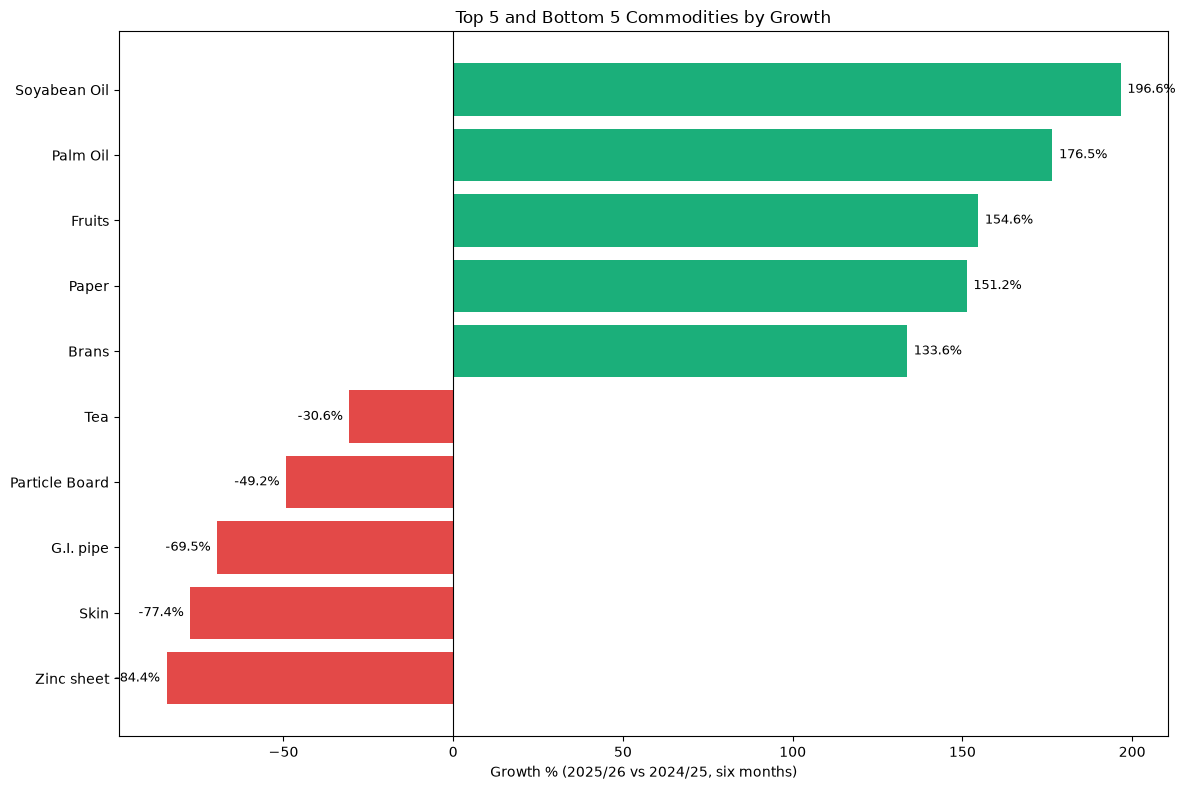

In [54]:
# find top5 commodities
top5 = df.nlargest(5, '2025/26 Growth %')[['Commodities', '2025/26 Growth %']]
# find bottom5 commodities
bottom5 = df.nsmallest(5, '2025/26 Growth %')[['Commodities', '2025/26 Growth %']]
print(top5)
print(bottom5)

# Combine top and bottom into one dataframe, sorted for a clean diverging look
combined = pd.concat([top5, bottom5]).sort_values('2025/26 Growth %', ascending=True)

labels = combined['Commodities'].tolist()
values = combined['2025/26 Growth %'].tolist()

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(labels))
colors = ['#e34948' if v < 0 else '#1baf7a' for v in values]  # red for decline, green for growth
bars = ax.barh(y_pos, values, align='center', color=colors)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.axvline(0, color='black', linewidth=0.8)  # zero baseline
ax.set_xlabel('Growth % (2025/26 vs 2024/25, six months)')
ax.set_title('Top 5 and Bottom 5 Commodities by Growth')

# Add percentage labels at the end of each bar
for bar, v in zip(bars, values):
    width = bar.get_width()
    label_x = width + (2 if width >= 0 else -2)   # small offset outward from bar end
    ha = 'left' if width >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

In [55]:
topp5 = df.nlargest(5, '2024/25 Growth %')[['Commodities', '2024/25 Growth %']]
bottomm5 = df.nsmallest(5, '2024/25 Growth %')[['Commodities', '2024/25 Growth %']]

print(topp5)
print(bottomm5)

TypeError: Column '2024/25 Growth %' has dtype object, cannot use method 'nlargest' with this dtype

Calculating mean by using in built pandas functions

In [ ]:
mean_202324_annual = df["2023/24 Annual"].mean().round(2)
mean_202425_annual = df["2024/25 Annual"].mean().round(2)
mean_202324_sixmnth = df["2023/24 Six Months"].mean().round(2)
mean_202425_sixmnth = df["2024/25 Six Months"].mean().round(2)
mean_202526_sixmnth = df["2025/26 Six Months"].mean().round(2)

print(f"2023/24 Annual Mean: {mean_202324_annual}")
print(f"2024/25 Annual Mean: {mean_202425_annual}")
print(f"2023/24 Six Months Mean: {mean_202324_sixmnth}")
print(f"2024/25 Six Months Mean: {mean_202425_sixmnth}")
print(f"2025/26 Six Months Mean: {mean_202526_sixmnth}")



2023/24 Annual Mean: 2337.28
2024/25 Annual Mean: 5143.96
2023/24 Six Months Mean: 1166.86
2024/25 Six Months Mean: 1633.66
2025/26 Six Months Mean: 2701.41


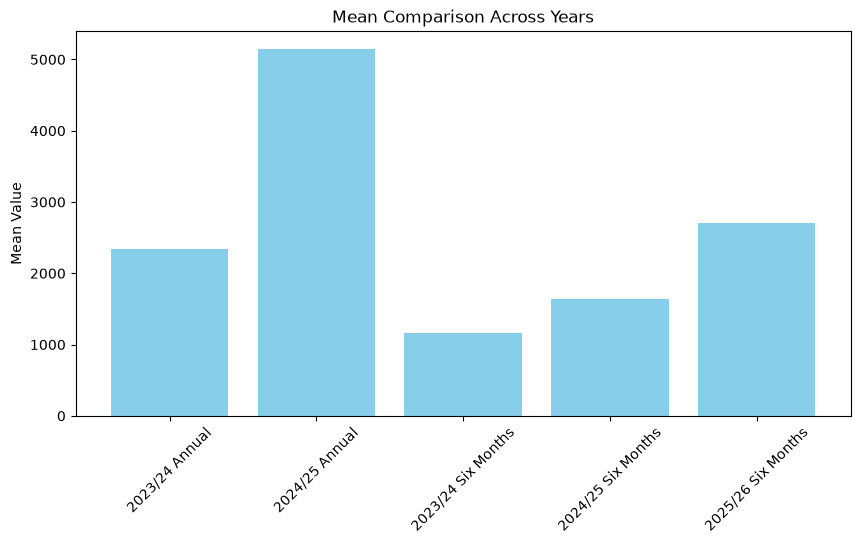

In [ ]:
means = {
    "2023/24 Annual": df["2023/24 Annual"].mean().round(2),
    "2024/25 Annual": df["2024/25 Annual"].mean().round(2),
    "2023/24 Six Months": df["2023/24 Six Months"].mean().round(2),
    "2024/25 Six Months": df["2024/25 Six Months"].mean().round(2),
    "2025/26 Six Months": df["2025/26 Six Months"].mean().round(2)
}

plt.figure(figsize=(10,5))
plt.bar(means.keys(), means.values(), color="skyblue")

plt.title("Mean Comparison Across Years")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

Calculating Median

In [ ]:
median = median_202324_annual = df["2023/24 Annual"].median().round(2)
median_202425_annual = df["2024/25 Annual"].median().round(2)
median_202324_sixmnth = df["2023/24 Six Months"].median().round(2)
median_202425_sixmnth = df["2024/25 Six Months"].median().round(2)
median_202526_sixmnth = df["2025/26 Six Months"].median().round(2)

print(median_202324_annual)
print(median_202425_annual)
print(median_202324_sixmnth)
print(median_202425_sixmnth)
print(median_202526_sixmnth)

918.6
1045.55
433.55
426.63
592.67


In [ ]:
# Comparing mean vs median
diff = mean_202324_annual - median_202324_annual
print(f"\n Mean - Median = {diff:.2f}")


 Mean - Median = 1418.68


In [ ]:
if diff > 0:
    print("Mean value is greater than Median and data is right skewed")
elif diff < 0:
    print("Mean is less than median or data is left skewed")
else:
    print("Mean = Meadian -> data is roughly symmetric")

Mean value is greater than Median and data is right skewed


In [ ]:
all_columns = [
    "2023/24 Annual", "2023/24 Six Months",
    "2024/25 Annual", "2024/25 Six Months",
    "2025/26 Six Months"
]

for c in all_columns:
    mean_c = df[c].mean()
    median_c = df[c].median()
    print(f"\n{c}")
    print(f"  Mean:   {mean_c:.2f}")
    print(f"  Median: {median_c:.2f}")
    print(f"  Std:    {df[c].std():.2f}")
    print(f"  Skew?   {'Right-skewed (mean > median)' if mean_c > median_c else 'Left-skewed or symmetric'}")


2023/24 Annual
  Mean:   2337.28
  Median: 918.60
  Std:    3142.58
  Skew?   Right-skewed (mean > median)

2023/24 Six Months
  Mean:   1166.86
  Median: 433.55
  Std:    1544.03
  Skew?   Right-skewed (mean > median)

2024/25 Annual
  Mean:   5143.96
  Median: 1045.55
  Std:    17236.06
  Skew?   Right-skewed (mean > median)

2024/25 Six Months
  Mean:   1633.66
  Median: 426.63
  Std:    3282.77
  Skew?   Right-skewed (mean > median)

2025/26 Six Months
  Mean:   2701.41
  Median: 592.67
  Std:    9060.13
  Skew?   Right-skewed (mean > median)


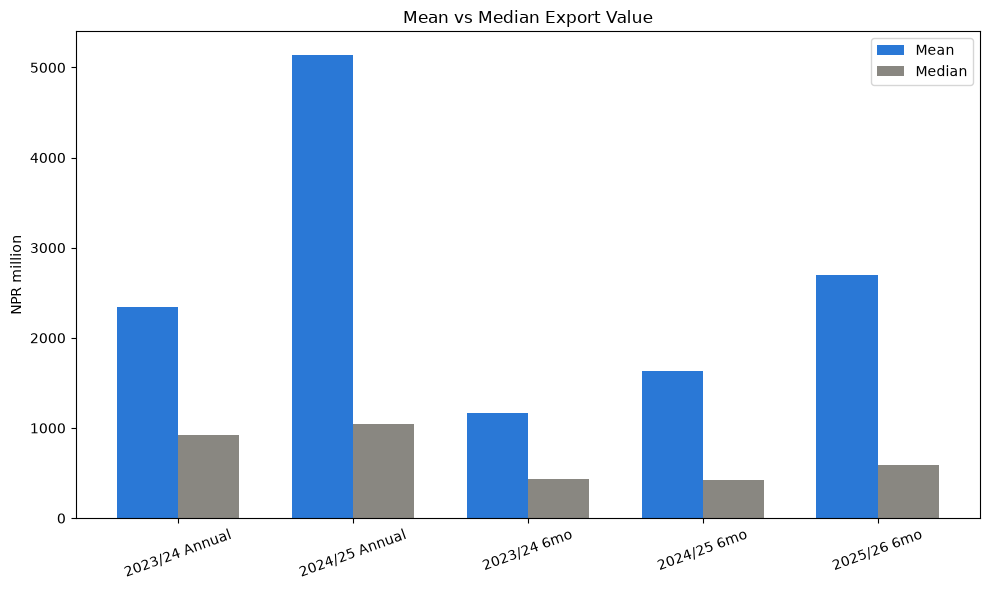

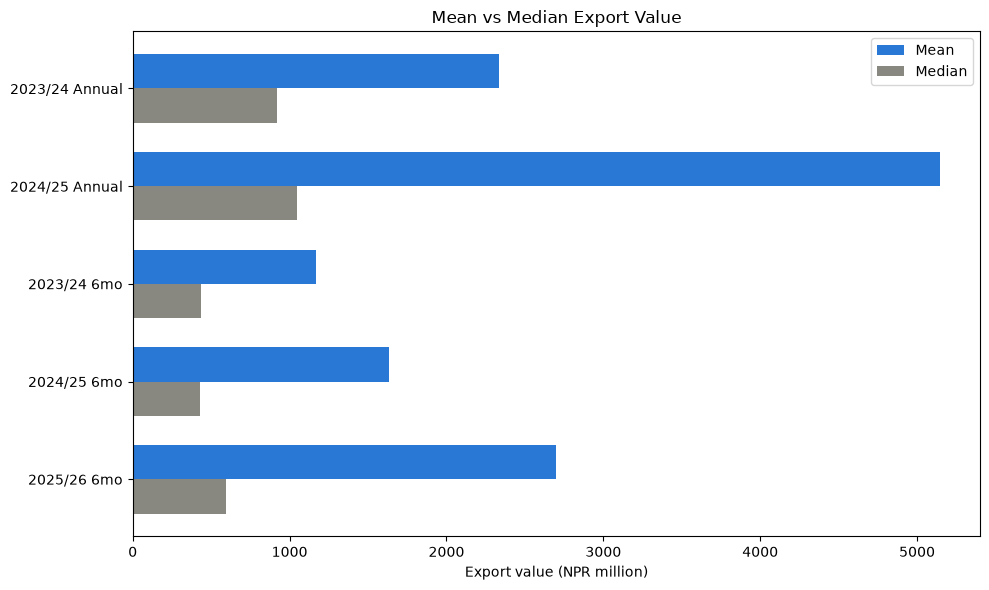

In [ ]:
periods = ["2023/24 Annual", "2024/25 Annual", "2023/24 6mo", "2024/25 6mo", "2025/26 6mo"]
means = [mean_202324_annual, mean_202425_annual, mean_202324_sixmnth,mean_202425_sixmnth,mean_202526_sixmnth]
medians = [median_202324_annual,median_202425_annual,median_202324_sixmnth,median_202425_sixmnth,median_202526_sixmnth]

x = np.arange(len(periods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, means, width, label="Mean", color="#2a78d6")
ax.bar(x + width/2, medians, width, label="Median", color="#898781")

ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=20)
ax.set_ylabel("NPR million")
ax.set_title("Mean vs Median Export Value")
ax.legend()
plt.tight_layout()
plt.show()


y_pos = np.arange(len(periods))
height = 0.35  # thickness of each bar, controls spacing between the pair

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(y_pos - height/2, means, height=height, label='Mean', color='#2a78d6')
ax.barh(y_pos + height/2, medians, height=height, label='Median', color='#888780')

ax.set_yticks(y_pos)
ax.set_yticklabels(periods)
ax.invert_yaxis()  # top-to-bottom order
ax.set_xlabel('Export value (NPR million)')
ax.set_title('Mean vs Median Export Value')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
std_202324_annual = df["2023/24 Annual"].std().round(2)
std_202425_annual = df["2024/25 Annual"].std().round(2)
std_202324_sixmnth = df["2023/24 Six Months"].std().round(2)
std_202425_sixmnth = df["2024/25 Six Months"].std().round(2)
std_202526_sixmnth = df["2025/26 Six Months"].std().round(2)

print(std_202324_annual)
print(std_202425_annual)
print(std_202324_sixmnth)
print(std_202425_sixmnth)
print(std_202526_sixmnth)

3142.58
17236.06
1544.03
3282.77
9060.13


In [ ]:
# finding three six-months columns  cv
sixmonth_cols = ['2023/24 Six Months', '2024/25 Six Months', '2025/26 Six Months']
df['mean'] = df[sixmonth_cols].mean(axis=1)
df['std'] = df[sixmonth_cols].std(axis=1) #axis=1 tells pandas to perform the operation across columns, row by row (i.e., horizontally) instead of down each column.
# df['CV_%'] = (df['std'] / df['mean']) * 100

# print(df['mean'])
# print(df['std'])

print(df['std'].isnull().sum())          # NaN count (from mean=0, if any)
# print(np.isinf(df['CV_%']).sum())          # inf count (also from mean=0 cases)

# print(df[['Commodities', 'mean', 'std', 'CV_%']].sort_values('CV_%', ascending=False))

0


In [ ]:
corr1 = df["2023/24 Annual"].corr(df["2024/25 Annual"])
corr2 = df["2023/24 Six Months"].corr(df["2024/25 Six Months"])
print(f"The Correlation for  2023/24 Annual and 2024/25 Annual is: {corr1}")
print(f"The Correlation for  2023/24 Six Months and 2024/25 Six Months is: {corr2}")


The Correlation for  2023/24 Annual and 2024/25 Annual is: 0.1015546023510467
The Correlation for  2023/24 Six Months and 2024/25 Six Months is: 0.3794875084593097


0.1015546023510467


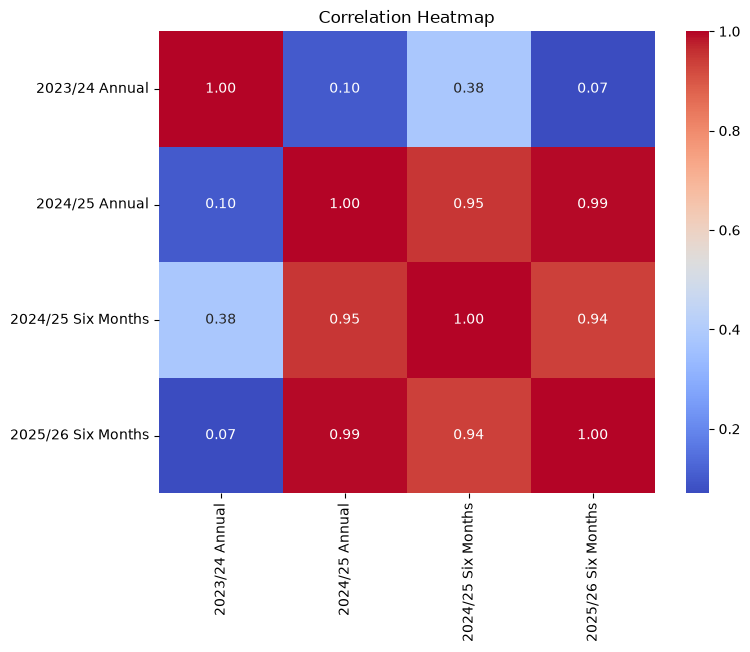

In [ ]:
corr1 = df["2023/24 Annual"].corr(df["2024/25 Annual"])

print(corr1)


cols = [
    "2023/24 Annual",
    "2024/25 Annual",
    "2024/25 Six Months",
    "2025/26 Six Months"
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
cols = [
    "2023/24 Annual",
    "2024/25 Annual",
    "2023/24 Six Months",
    "2024/25 Six Months"
]

corr_matrix = df[cols].corr().round(2)
print(corr_matrix)

                    2023/24 Annual  2024/25 Annual  2023/24 Six Months  \
2023/24 Annual                1.00            0.10                0.99   
2024/25 Annual                0.10            1.00                0.10   
2023/24 Six Months            0.99            0.10                1.00   
2024/25 Six Months            0.38            0.95                0.38   

                    2024/25 Six Months  
2023/24 Annual                    0.38  
2024/25 Annual                    0.95  
2023/24 Six Months                0.38  
2024/25 Six Months                1.00  


In [ ]:
highest = df.loc[df["2023/24 Annual"].idxmax()]
print(highest)

lowest = df.loc[df["2024/25 Annual"].idxmin()]
print(lowest)

S.N.                     36.000000
Commodities                    NaN
2023/24 Annual        11858.045690
2023/24 Six Months     6085.189136
2024/25 Annual        10108.486376
2024/25 Six Months     4515.373418
2025/26 Six Months      702.792862
2024/25 Growth %        -25.797320
2025/26 Growth %        -84.435554
Name: 37, dtype: float64
S.N.                  3.000
Commodities             NaN
2023/24 Annual        0.061
2023/24 Six Months    0.061
2024/25 Annual        0.000
2024/25 Six Months    0.000
2025/26 Six Months    0.000
2024/25 Growth %      0.000
2025/26 Growth %      0.000
Name: 2, dtype: float64


In [ ]:
df.describe()

,2024/25 Annual,2025/26 Growth %
count,38.000000,38.000000
mean,5143.959719,30.888457
std,17236.057580,66.683214
min,0.000000,-84.435554
25%,134.883369,-4.034283
50%,1045.545997,17.348855
75%,3495.183627,62.130659
max,106790.819514,196.576152


In [ ]:
# checking empty data or data handling
print(df.isnull().sum())

# checking du-plicates data
print(df.duplicated().sum())

S.N.                  2
Commodities           0
2023/24 Annual        0
2023/24 Six Months    0
2024/25 Annual        0
2024/25 Six Months    0
2025/26 Six Months    0
2024/25 Growth %      0
2025/26 Growth %      0
dtype: int64
0


The bar chart sh

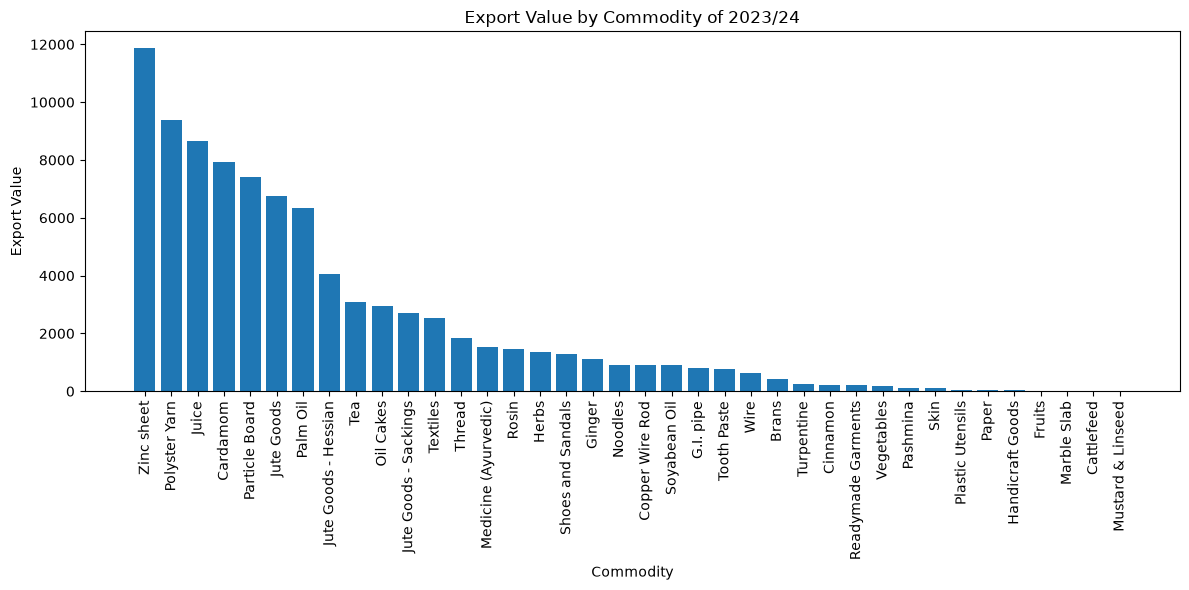

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df = df.sort_values(by="2023/24 Annual", ascending=False)
plt.bar(df["Commodities"], df["2023/24 Annual"])

plt.xlabel("Commodity")
plt.ylabel("Export Value")
plt.title("Export Value by Commodity of 2023/24")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Zinch Sheet had the highest export value during 2023/24, followed by polyster yarn, while fruits accounted
for a comparatively smaller share of imports. The differences in bar heights indicate that import values varied substantially across commodities.

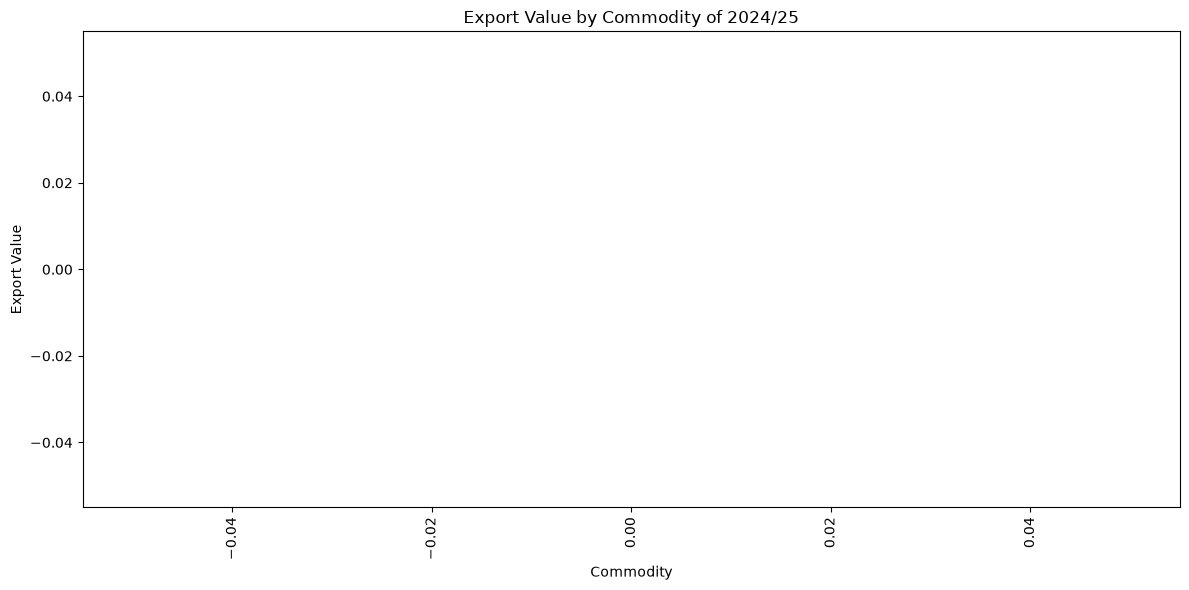

In [ ]:
plt.figure(figsize = (12,6))

plt.bar(df["Commodities"], df["2024/25 Annual"])

plt.xlabel("Commodity")
plt.ylabel("Export Value")
plt.title("Export Value by Commodity of 2024/25")

plt.xticks(rotation = 90)
plt.tight_layout()

Bar Chart Show Soyabean oil is the largest export commodity in 2024/25 year.

In [ ]:
# checking empty data or data handling
print(df.isnull().sum())

# checking du-plicates data
print(df.duplicated().sum())

S.N.                   2
Commodities           38
2023/24 Annual         0
2023/24 Six Months     0
2024/25 Annual         0
2024/25 Six Months     0
2025/26 Six Months     0
2024/25 Growth %       0
2025/26 Growth %       0
dtype: int64
0


In [ ]:
#  Convert to a numeric float or integer
df = df.apply(pd.to_numeric, errors='coerce')

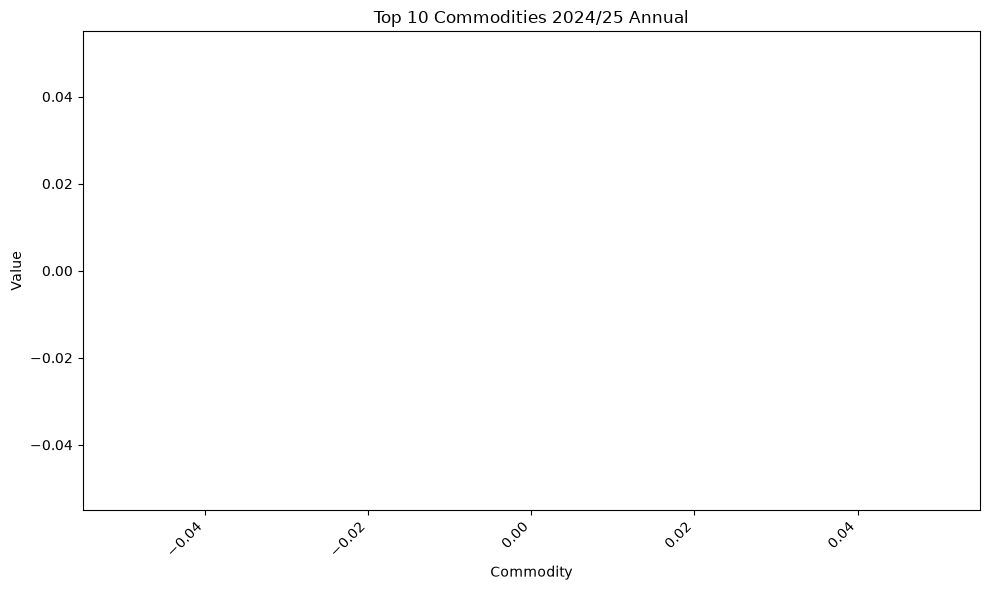

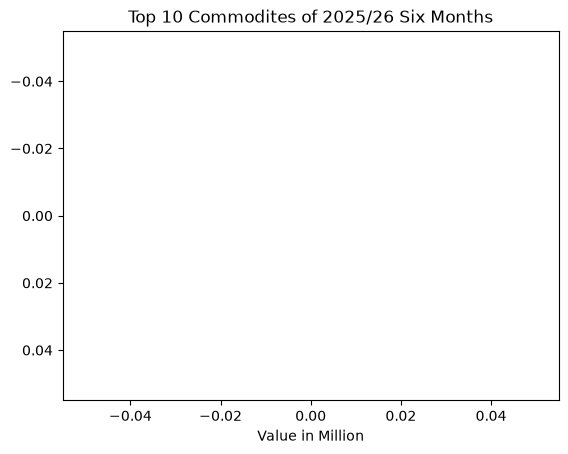

In [ ]:
# select the 10 rows with largest value in column 3
top10 = df.nlargest(10, "2024/25 Annual")
# create a figure with a width of 10 inches and height 0f 6 inches
plt.figure(figsize = (10, 6))

# create a bar chart
# x -axis: comodity names (columns 2)
# y-axis:Values(column(3))
plt.bar(top10["Commodities"], top10["2024/25 Annual"])

plt.xlabel("Commodity")
plt.ylabel("Value")
plt.title("Top 10 Commodities 2024/25 Annual")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

#horizontal bar chart
fig, ax = plt.subplots()
ax.barh(top10["Commodities"],top10["2025/26 Six Months"], align='center')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
ax.set_xlabel('Value in Million')
ax.set_title('Top 10 Commodites of 2025/26 Six Months')

plt.show()

Soyabean oil purely dominates the whole export

In [ ]:
print(top10)

    S.N.  Commodities  2023/24 Annual  2023/24 Six Months  2024/25 Annual  \
29  28.0          NaN      901.804751          415.193316   106790.819514   
24  23.0          NaN     9382.523442         4548.345933    12335.018810   
37  36.0          NaN    11858.045690         6085.189136    10108.486376   
11  12.0          NaN     6755.776356         3625.598887     8222.942050   
10  11.0          NaN     8658.685444         3760.637317     7703.781897   
1    2.0          NaN     7936.619600         3907.678400     7674.036648   
21  20.0          NaN     7415.322247         3530.322941     7099.647606   
12   NaN          NaN     4040.570144         2145.910177     5690.120311   
30  29.0          NaN     3093.406264         1865.805247     3983.289142   
18  17.0          NaN     2955.789925         1383.739179     3629.816606   

    2024/25 Six Months  2025/26 Six Months  2024/25 Growth %  2025/26 Growth %  
29        18909.958030        56082.425848          0.000000        196

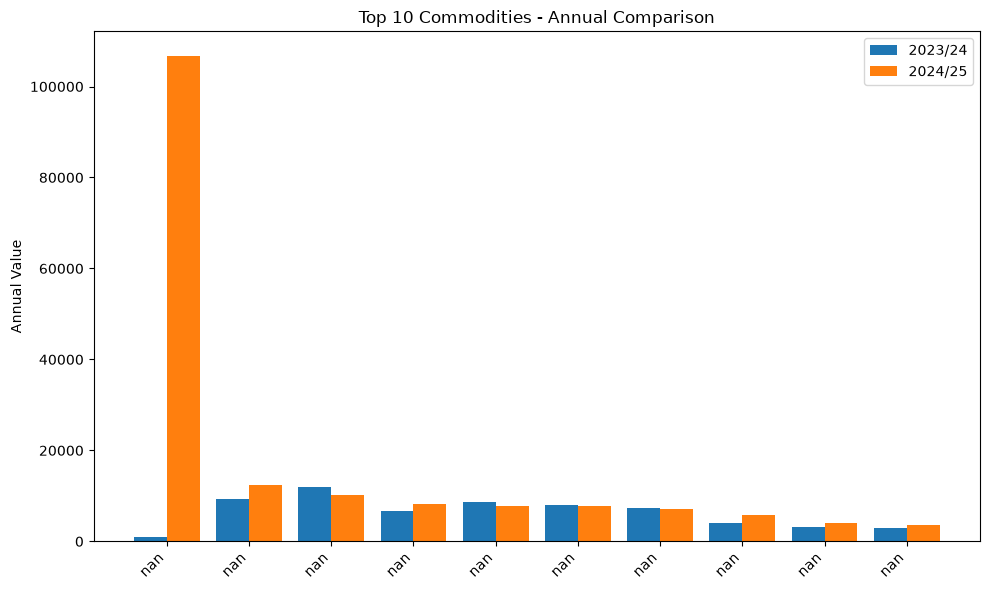

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_annual = top10[['Commodities', '2023/24 Annual', '2024/25 Annual']]

labels = df_annual['Commodities'].tolist()
x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width/2, df_annual['2023/24 Annual'], width, label='2023/24')
ax.bar(x + width/2, df_annual['2024/25 Annual'], width, label='2024/25')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

ax.set_ylabel("Annual Value")
ax.set_title("Top 10 Commodities - Annual Comparison")
ax.legend()

plt.tight_layout()
plt.show()

These above shows the top 10 commodities of 2024/25 Annual.

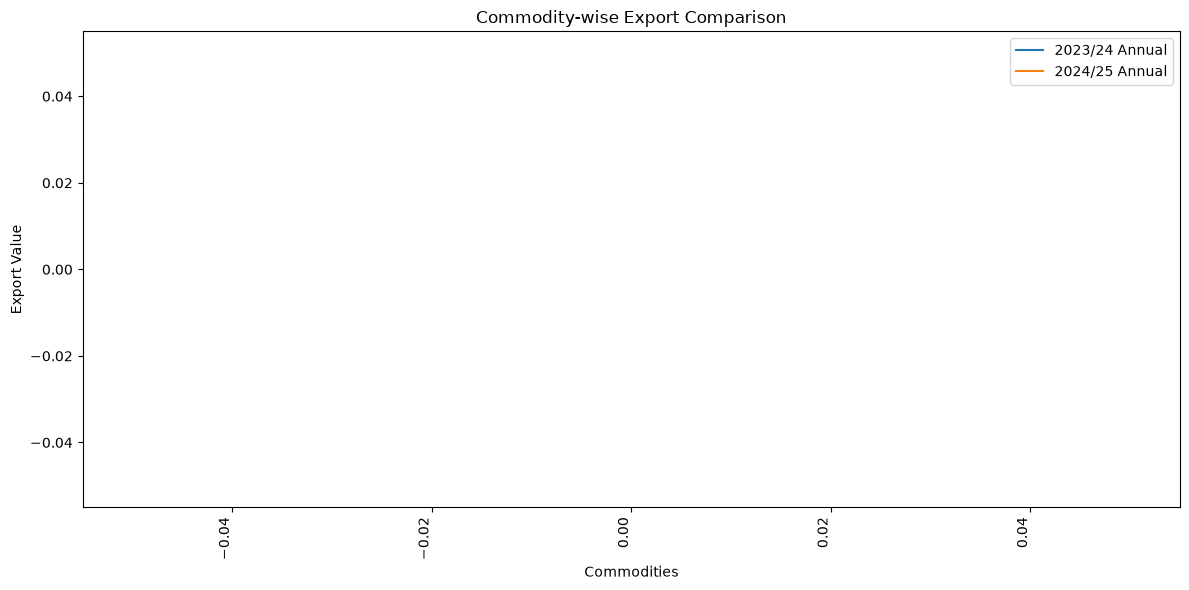

In [ ]:
plt.figure(figsize =(12,6))
plt.plot(df["Commodities"], df["2023/24 Annual"],label = "2023/24 Annual")
plt.plot(df["Commodities"], df["2024/25 Annual"],label = "2024/25 Annual")

plt.title("Commodity-wise Export Comparison")
plt.xlabel("Commodities")
plt.ylabel("Export Value")
plt.legend()
plt.xticks(rotation=90, ha="right")
plt.tight_layout()

plt.show()


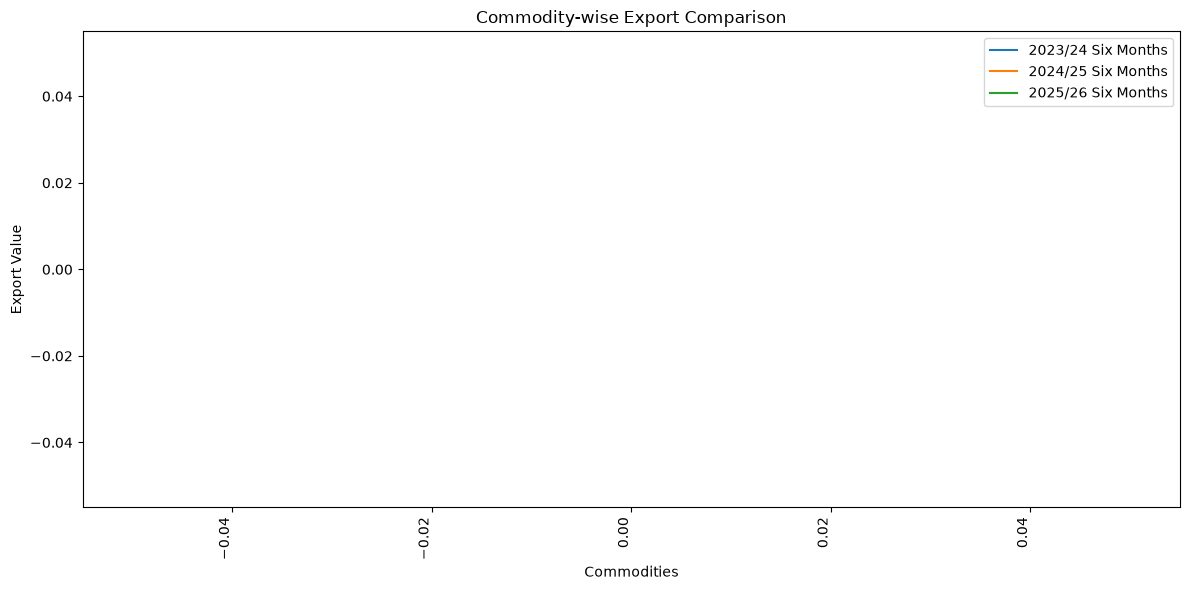

In [ ]:
plt.figure(figsize =(12,6))
plt.plot(df["Commodities"], df["2023/24 Six Months"], label="2023/24 Six Months")
plt.plot(df["Commodities"], df["2024/25 Six Months"], label="2024/25 Six Months")
plt.plot(df["Commodities"], df["2025/26 Six Months"], label="2025/26 Six Months")

plt.title("Commodity-wise Export Comparison")
plt.xlabel("Commodities")
plt.ylabel("Export Value")
plt.legend()
plt.xticks(rotation=90, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
df['2024/25 Annual'] = pd.to_numeric(df['2024/25 Annual'], errors='coerce')


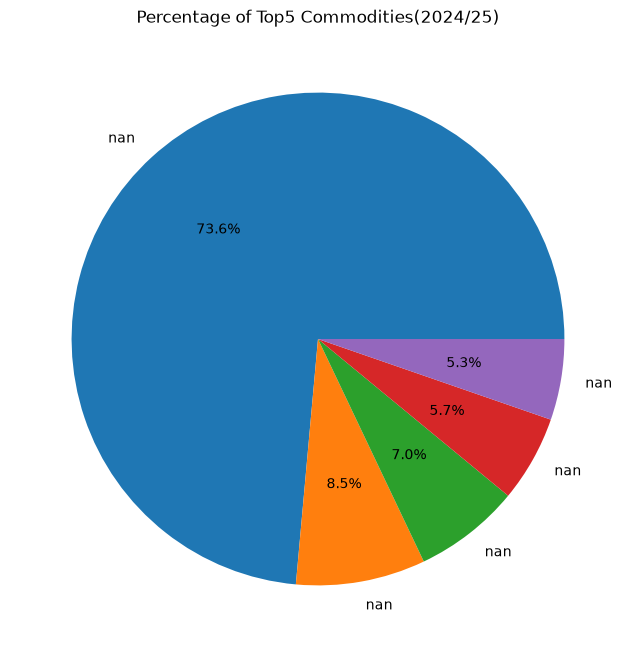

In [ ]:
top5 = df.nlargest(5, "2024/25 Annual")

plt.figure(figsize=(8,8))

plt.pie(
    top5["2024/25 Annual"],
    labels=top5["Commodities"],
    autopct="%1.1f%%",
)
plt.title("Percentage of Top5 Commodities(2024/25)")

plt.show()



Soyabean has highest export percentage among top5

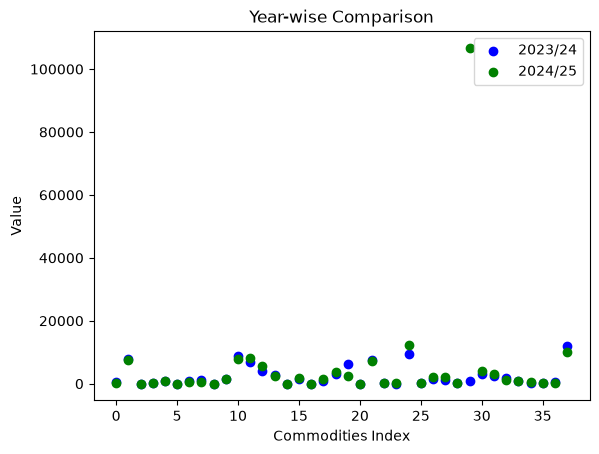

In [ ]:
plt.scatter(df.index, df["2023/24 Annual"], color="blue", label="2023/24")
plt.scatter(df.index, df["2024/25 Annual"], color="green", label="2024/25")

plt.xlabel("Commodities Index")
plt.ylabel("Value")
plt.title("Year-wise Comparison")
plt.legend()
plt.show()

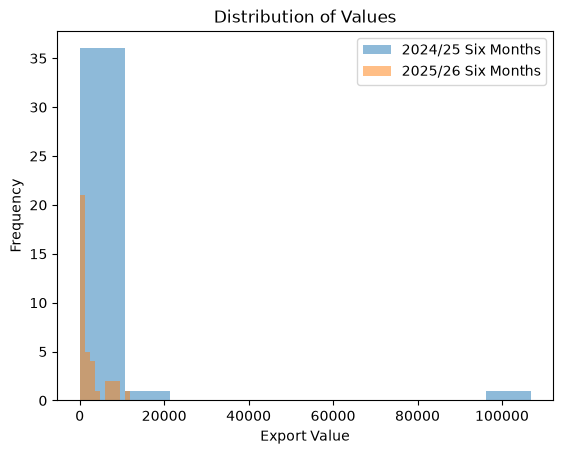

In [ ]:
plt.hist(df["2024/25 Annual"], bins=10, alpha=0.5, label="2024/25 Six Months")
plt.hist(df["2023/24 Annual"], bins=10, alpha=0.5, label="2025/26 Six Months")

plt.title("Distribution of Values")
plt.xlabel("Export Value")
plt.ylabel("Frequency")

plt.legend()

plt.show()

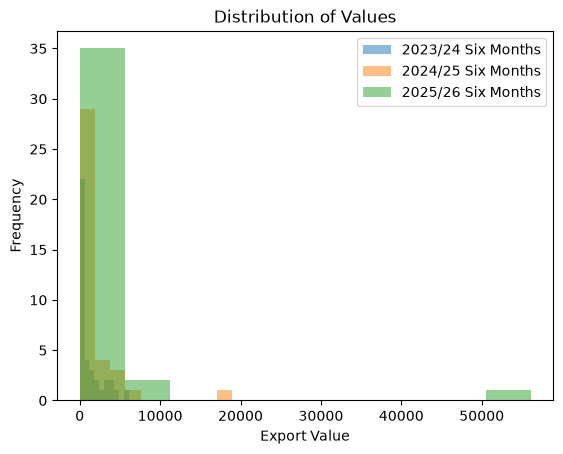

In [ ]:
plt.hist(df["2023/24 Six Months"], bins=10, alpha=0.5, label="2023/24 Six Months")
plt.hist(df["2024/25 Six Months"], bins=10, alpha=0.5, label="2024/25 Six Months")
plt.hist(df["2025/26 Six Months"], bins=10, alpha=0.5, label="2025/26 Six Months")

plt.title("Distribution of Values")
plt.xlabel("Export Value")
plt.ylabel("Frequency")

plt.legend()

plt.show()

3.11.0


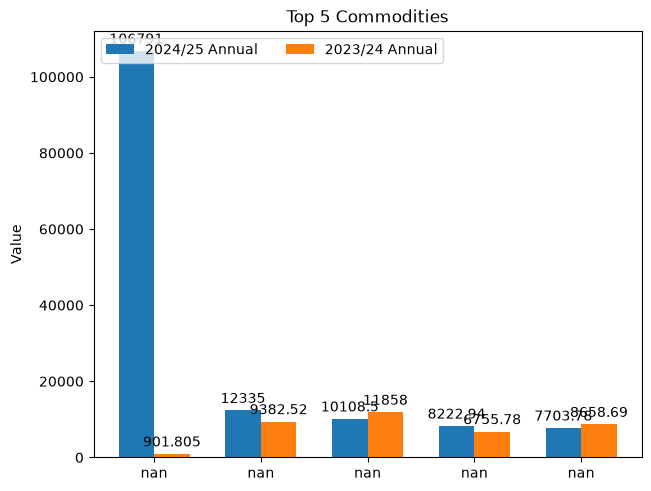

In [ ]:
import matplotlib
print(matplotlib.__version__)
top5 = df.nlargest(5, "2024/25 Annual")

species = tuple(top5['Commodities'])

penguin_means = {
    '2024/25 Annual': tuple(top5['2024/25 Annual']),
    '2023/24 Annual': tuple(top5['2023/24 Annual']),
}

fig, ax = plt.subplots(layout='constrained')

res = ax.grouped_bar(penguin_means, tick_labels=species, group_spacing=1)

for container in res.bar_containers:
    ax.bar_label(container, padding=3)

ax.set_ylabel('Value')
ax.set_title('Top 5 Commodities')
ax.legend(loc='upper left', ncols=3)

plt.show()

In [ ]:
# checking empty data or data handling
print(df.isnull().sum())

# checking du-plicates data
print(df.duplicated().sum())

S.N.                   2
Commodities           38
2023/24 Annual         0
2023/24 Six Months     0
2024/25 Annual         0
2024/25 Six Months     0
2025/26 Six Months     0
2024/25 Growth %       0
2025/26 Growth %       0
dtype: int64
0


In [ ]:
# checking empty data or data handling
print(df.isnull().sum())

# checking du-plicates data
print(df.duplicated().sum())

S.N.                   2
Commodities           38
2023/24 Annual         0
2023/24 Six Months     0
2024/25 Annual         0
2024/25 Six Months     0
2025/26 Six Months     0
2024/25 Growth %       0
2025/26 Growth %       0
dtype: int64
0


In [ ]:
print(df.columns.tolist())

['S.N.', 'Commodities', '2023/24 Annual', '2023/24 Six Months', '2024/25 Annual', '2024/25 Six Months', '2025/26 Six Months', '2024/25 Growth %', '2025/26 Growth %']
